In [12]:
# E) Naka–Rushton (3-param)
def naka(c, Rmax, c50, n):
    c = np.asarray(c, float)
    return Rmax * (c**n) / (c**n + c50**n)

def fit_naka(contrasts, y, fix_n=None):
    c = np.asarray(contrasts, float); y = np.asarray(y, float)
    if fix_n is None:
        p0     = [1.0, np.median(c)/2.0, 2.0]
        bounds = ([0.0, c.min()/10.0, 1.0], [np.inf, c.max(), 6.0])
        popt, pcov = curve_fit(naka, c, y, p0=p0, bounds=bounds, maxfev=20000)
        return popt, pcov
    else:
        def naka_fixed(c_, Rmax, c50): return naka(c_, Rmax, c50, fix_n)
        p0     = [1.0, np.median(c)/2.0]
        bounds = ([0.0, c.min()/10.0], [np.inf, c.max()])
        popt2, pcov2 = curve_fit(naka_fixed, c, y, p0=p0, bounds=bounds, maxfev=20000)
        Rmax, c50 = popt2
        return (Rmax, c50, fix_n), pcov2


In [ ]:
# %% CRF overlay + NR parameter summaries for all three pathways

import numpy as np, matplotlib.pyplot as plt, glob, os
from pathlib import Path
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import norm

# ---- directories and contrasts (adjust if your folder names differ) ----
DIRS = {
    "Luminance": "/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/Luminance_NPZ/ecoc_results_01",
    "L-M":       "/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/L_M_NPZ/ecoc_results_01",
    "S-cone":    "/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/S_cone_NPZ/ecoc_results_01",
}
CONTRASTS = {
    "Luminance": np.array([0.035, 0.07, 0.14, 0.28], float),
    "L-M":       np.array([0.008, 0.016, 0.032, 0.064], float),
    "S-cone":    np.array([0.06,  0.12,  0.24,  0.48], float),
}
ORDER  = ["Luminance", "L-M", "S-cone"]
COLORS = {
    "Luminance": "#808080",  # Dark Gray (Achromatic)
    "L-M":       "#D62728",  # Red (Red-Green pathway)
    "S-cone":    "#1F77B4",  # Blue (Blue-Yellow/S-cone pathway)
}


TIME_RANGE_PICK = (0.05, 0.30)  
FIXED_TIME      = 0.15          
MIN_SUBJ_CRV    = 10            


def _subjects_in_dir(results_dir):
    files = glob.glob(os.path.join(results_dir, "sub-*_*nr_timecourses.npz"))
    return sorted({Path(f).stem.split("_")[0] for f in files})

def _load_nr(results_dir, sid):
    f = Path(results_dir) / f"{sid}_nr_timecourses.npz"
    if not f.exists(): return None
    with np.load(f, allow_pickle=False) as d:
        return {
            "time": d["time"].astype(float),
            "X": d["X"].astype(float),         
            "qc": d["qc_mask"].astype(bool)
        }

def _pick_window_idx(nr):
    T, qc = nr["time"], nr["qc"]
    ok = np.where(qc)[0]
    within = (T >= TIME_RANGE_PICK[0]) & (T <= TIME_RANGE_PICK[1])
    cand = np.intersect1d(np.where(within)[0], ok)
    if cand.size:
        Xi = nr["X"][cand, :].mean(axis=1)
        return int(cand[np.argmax(Xi)])
    if ok.size:
        return int(ok[np.argmax(nr["X"][ok, :].mean(axis=1))])
    return int(np.argmin(np.abs(T - FIXED_TIME)))

def _collect_crf_matrix(results_dir, contrasts):
    """Return subjects×levels CRF at chosen window, and per-subject NR params (n fixed)."""
    sids = _subjects_in_dir(results_dir)
    rows = []; params = []
    for sid in sids:
        nr = _load_nr(results_dir, sid)
        if nr is None: continue
        w = _pick_window_idx(nr)
        y = nr["X"][w, :].astype(float)
        rows.append(y)
        try:
            popt, _ = fit_naka(contrasts, y, fix_n=2.0)  # n fixed for stability
            Rmax, c50, n = map(float, popt)
            params.append({"subject": sid, "R_max": Rmax, "c50": c50, "n": n})
        except Exception:
            pass
    if not rows:
        raise RuntimeError(f"No subjects found in {results_dir}")
    return np.vstack(rows), pd.DataFrame(params)

# ---------- main plotting ----------
def plot_all_pathways_one_figure(dirs=DIRS, contrasts=CONTRASTS,
                                 order=ORDER, colors=COLORS,
                                 out_png=Path("/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP")/"CRF_NRparams_all_pathways.png",
                                 out_csv=Path("/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP")/"NR_params_all_pathways.csv"):
    # gather data
    group_curves = {}   
    df_all = []      
    for name in order:
        Xmat, dfp = _collect_crf_matrix(dirs[name], contrasts[name])
        mu = np.nanmean(Xmat, axis=0)
        se = np.nanstd(Xmat, axis=0, ddof=1) / np.sqrt(Xmat.shape[0])

        # fit to group mean (n fixed)
        popt, _ = fit_naka(contrasts[name], mu, fix_n=2.0)
        Rg, c50g, ng = map(float, popt)
        cc  = np.linspace(float(contrasts[name].min()), float(contrasts[name].max())*1.5, 400)
        yfit= naka(cc, Rg, c50g, ng)
        group_curves[name] = (mu, se, (Rg, c50g, ng), cc, yfit)
        if not dfp.empty:
            dfp = dfp.assign(pathway=name)
            df_all.append(dfp)

    df_params_all = pd.concat(df_all, ignore_index=True) if df_all else pd.DataFrame()

    # figure: left (wide) CRF overlay; right two rows: Rmax and c50 distributions
    fig = plt.figure(figsize=(12, 4.6))
    gs  = fig.add_gridspec(2, 2, width_ratios=[1.5, 1.0], height_ratios=[1,1], wspace=0.28, hspace=0.32)

    # --- Left: CRF overlay ---
    ax0 = fig.add_subplot(gs[:,0])
    for name in order:
        mu, se, (Rg, c50g, ng), cc, yfit = group_curves[name]
        col = colors[name]
        # mean ± SEM points
        ax0.errorbar(contrasts[name], mu, yerr=se, fmt="o", ms=5, color=col, ecolor=col, alpha=0.9, capsize=3, label=name)
        # fitted curve
        ax0.plot(cc, yfit, color=col, lw=2)
    ax0.set_xlabel("Contrast"); ax0.set_ylabel("Response (MDS units)")
    ax0.set_title("Group CRFs (n fixed=2)"); ax0.legend(frameon=False)

    # --- Right-top: Rmax by pathway (box + jitter) ---
    ax1 = fig.add_subplot(gs[0,1])
    if not df_params_all.empty:
        dataR = [df_params_all.loc[df_params_all["pathway"]==name, "R_max"].dropna().to_numpy(float) for name in order]
        ax1.boxplot(dataR, labels=order, showfliers=False)
        # jittered scatter
        for i, name in enumerate(order, start=1):
            xj = i + (np.random.rand((df_params_all["pathway"]==name).sum())-0.5)*0.15
            yj = df_params_all.loc[df_params_all["pathway"]==name, "R_max"].to_numpy(float)
            ax1.scatter(xj, yj, s=15, color=colors[name], alpha=0.6)
        ax1.set_ylabel("R_max (a.u.)")
        ax1.set_title("Max response across subjects")
    else:
        ax1.text(0.5,0.5,"No parameter data",ha="center",va="center",transform=ax1.transAxes)

    # --- Right-bottom: c50 by pathway (box + jitter) ---
    ax2 = fig.add_subplot(gs[1,1])
    if not df_params_all.empty:
        dataC = [df_params_all.loc[df_params_all["pathway"]==name, "c50"].dropna().to_numpy(float) for name in order]
        ax2.boxplot(dataC, labels=order, showfliers=False)
        for i, name in enumerate(order, start=1):
            xj = i + (np.random.rand((df_params_all["pathway"]==name).sum())-0.5)*0.15
            yj = df_params_all.loc[df_params_all["pathway"]==name, "c50"].to_numpy(float)
            ax2.scatter(xj, yj, s=15, color=colors[name], alpha=0.6)
        ax2.set_ylabel("c50 (contrast)")
        ax2.set_title("Half-contrast across subjects")
    else:
        ax2.text(0.5,0.5,"No parameter data",ha="center",va="center",transform=ax2.transAxes)

    fig.tight_layout()
    fig.savefig(out_png, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print("Saved figure:", out_png)

    # Save the parameters to CSV 
    df_params_all.to_csv(out_csv, index=False)
    print("Saved parameters table:", out_csv)


    if not df_params_all.empty:
        for name in order:
            sub = df_params_all[df_params_all["pathway"]==name]
            print(f"{name}: n={len(sub)} | R_max mean±SEM = {sub['R_max'].mean():.3f} ± {sub['R_max'].std(ddof=1)/np.sqrt(len(sub)):.3f} | "
                  f"c50 mean±SEM = {sub['c50'].mean():.3f} ± {sub['c50'].std(ddof=1)/np.sqrt(len(sub)):.3f}")


plot_all_pathways_one_figure()


Saved figure: /Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/CRF_NRparams_all_pathways.png
Saved parameters table: /Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/NR_params_all_pathways.csv
Luminance: n=35 | R_max mean±SEM = 1.165 ± 0.015 | c50 mean±SEM = 0.092 ± 0.004
L-M: n=35 | R_max mean±SEM = 1.172 ± 0.019 | c50 mean±SEM = 0.022 ± 0.001
S-cone: n=35 | R_max mean±SEM = 1.179 ± 0.012 | c50 mean±SEM = 0.163 ± 0.007


/var/folders/_t/52p8xpgs1gdctzqmjjcqm0zm0000gn/T/ipykernel_48589/2798734987.py:120: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(dataR, labels=order, showfliers=False)
/var/folders/_t/52p8xpgs1gdctzqmjjcqm0zm0000gn/T/ipykernel_48589/2798734987.py:135: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(dataC, labels=order, showfliers=False)
/var/folders/_t/52p8xpgs1gdctzqmjjcqm0zm0000gn/T/ipykernel_48589/2798734987.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


In [7]:
# %% CRF + NR parameters for THREE pathways 

import numpy as np, matplotlib.pyplot as plt, glob, os
from pathlib import Path
import pandas as pd


DIRS = {
    "Luminance": "/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/Luminance_NPZ/ecoc_results_01",
    "L-M":       "/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/L_M_NPZ/ecoc_results_01",
    "S-cone":    "/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/S_cone_NPZ/ecoc_results_01",
}
CONTRASTS = {
    "Luminance": np.array([0.035, 0.07, 0.14, 0.28], float),
    "L-M":       np.array([0.008, 0.016, 0.032, 0.064], float),
    "S-cone":    np.array([0.06,  0.12,  0.24,  0.48], float),
}
ORDER  = ["Luminance", "L-M", "S-cone"]       
TIME_RANGE_PICK = (0.05, 0.30)               
FIXED_TIME      = 0.15                        

# ---------- helpers (shared) ----------
def _subjects_in_dir(results_dir):
    files = glob.glob(os.path.join(results_dir, "sub-*_*nr_timecourses.npz"))
    return sorted({Path(f).stem.split("_")[0] for f in files})

def _load_nr(results_dir, sid):
    f = Path(results_dir) / f"{sid}_nr_timecourses.npz"
    if not f.exists(): return None
    with np.load(f, allow_pickle=False) as d:
        return {"time": d["time"].astype(float),
                "X": d["X"].astype(float),         
                "qc": d["qc_mask"].astype(bool)}

def _pick_window_idx(nr, policy="subject_peak"):
    T, qc = nr["time"], nr["qc"]
    ok = np.where(qc)[0]
    if policy == "subject_peak":
        within = (T >= TIME_RANGE_PICK[0]) & (T <= TIME_RANGE_PICK[1])
        cand = np.intersect1d(np.where(within)[0], ok)
        if cand.size:
            Xi = nr["X"][cand, :].mean(axis=1)      
            return int(cand[np.argmax(Xi)])
        if ok.size:
            return int(ok[np.argmax(nr["X"][ok, :].mean(axis=1))])
        return int(np.argmin(np.abs(T - FIXED_TIME)))
    elif policy == "fixed":
        return int(np.argmin(np.abs(T - FIXED_TIME)))
    else:
        raise ValueError("policy must be 'subject_peak' or 'fixed'")

def _build_crf_and_params(results_dir, contrasts, policy="subject_peak"):
    rows, params = [], []
    for sid in _subjects_in_dir(results_dir):
        nr = _load_nr(results_dir, sid)
        if nr is None: continue
        w  = _pick_window_idx(nr, policy)
        y  = nr["X"][w, :].astype(float)           
        rows.append(y)
        try:
            popt, _ = fit_naka(contrasts, y, fix_n=2.0)  # n fixed for stability
            Rmax, c50, n = map(float, popt)
            params.append({"subject": sid, "R_max": Rmax, "c50": c50, "n": n})
        except Exception:
            pass
    if not rows:
        raise RuntimeError(f"No subjects in {results_dir}")
    return np.vstack(rows), pd.DataFrame(params)

def plot_crf_and_params(results_dir, contrasts, pathway, policy="subject_peak"):
    Xmat, dfp = _build_crf_and_params(results_dir, contrasts, policy)
    mu  = np.nanmean(Xmat, axis=0)
    se  = np.nanstd(Xmat, axis=0, ddof=1) / np.sqrt(Xmat.shape[0])
    popt,_ = fit_naka(contrasts, mu, fix_n=2.0)     
    Rg, c50g, ng = map(float, popt)
    cc  = np.linspace(float(contrasts.min()), float(contrasts.max())*1.5, 400)
    yg  = naka(cc, Rg, c50g, ng)

    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4.0))
    # CRF
    ax0.fill_between(contrasts, mu-se, mu+se, alpha=0.18, color=COLORS[pathway])
    ax0.plot(contrasts, mu, "o", color=COLORS[pathway], ms=6)
    ax0.plot(cc, yg, color=COLORS[pathway], lw=2, label=f"Fit (n={ng:.2f}, c50={c50g:.3f})")
    ax0.set_xlabel("Contrast"); ax0.set_ylabel("Response (MDS units)")
    ax0.set_title(f"{pathway}: Group CRF (n fixed)"); ax0.legend(frameon=False)
    # NR scatter
    if not dfp.empty:
        x = dfp["R_max"].to_numpy(float); y = dfp["c50"].to_numpy(float)
        ax1.scatter(x, y, s=35, facecolors="none", edgecolors=COLORS[pathway])
        xm, xs = np.nanmean(x), np.nanstd(x, ddof=1)/np.sqrt(len(x))
        ym, ys = np.nanmean(y), np.nanstd(y, ddof=1)/np.sqrt(len(y))
        ax1.axvline(xm, color=COLORS[pathway], lw=1, ls="--"); ax1.axhline(ym, color=COLORS[pathway], lw=1, ls="--")
        ax1.errorbar([xm], [ym], xerr=xs, yerr=ys, fmt="o", color=COLORS[pathway], capsize=3)
        ax1.set_xlabel("R_max"); ax1.set_ylabel("c50"); ax1.set_title("NR parameters across subjects")
    else:
        ax1.text(0.5,0.5,"No valid fits",ha="center",va="center",transform=ax1.transAxes)

    fig.tight_layout()
    out_dir = Path(results_dir)
    fig.savefig(out_dir / f"{pathway.replace(' ','_')}_CRF_NRparams.png", dpi=180, bbox_inches="tight")
    plt.close(fig)

    dfp.to_csv(out_dir / f"{pathway.replace(' ','_')}_NR_params.csv", index=False)
    return dfp.assign(pathway=pathway)


all_params = []
for name in ORDER:
    dfp = plot_crf_and_params(DIRS[name], CONTRASTS[name], name, policy="subject_peak")
    all_params.append(dfp)


df_all = pd.concat(all_params, ignore_index=True)
out_root = Path(DIRS[ORDER[0]]).parent  
df_all.to_csv(out_root / "NR_params_all_pathways.csv", index=False)
print("Saved combined:", out_root / "NR_params_all_pathways.csv")


Saved combined: /Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/Luminance_NPZ/NR_params_all_pathways.csv


In [8]:
# %%  CRFs + NR scatters for all three pathways

import numpy as np, matplotlib.pyplot as plt, glob, os
from pathlib import Path
import pandas as pd


DIRS = {
    "Luminance": "/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/Luminance_NPZ/ecoc_results_01",
    "L-M":       "/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/L_M_NPZ/ecoc_results_01",
    "S-cone":    "/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/S_cone_NPZ/ecoc_results_01",
}
CONTRASTS = {
    "Luminance": np.array([0.035, 0.07, 0.14, 0.28], float),
    "L-M":       np.array([0.008, 0.016, 0.032, 0.064], float),
    "S-cone":    np.array([0.06,  0.12,  0.24,  0.48], float),
}
ORDER  = ["Luminance", "L-M", "S-cone"]
TIME_RANGE_PICK = (0.05, 0.30)
FIXED_TIME      = 0.15


def _subjects_in_dir(results_dir):
    files = glob.glob(os.path.join(results_dir, "sub-*_*nr_timecourses.npz"))
    return sorted({Path(f).stem.split("_")[0] for f in files})

def _load_nr(results_dir, sid):
    f = Path(results_dir) / f"{sid}_nr_timecourses.npz"
    if not f.exists(): return None
    with np.load(f, allow_pickle=False) as d:
        return {"time": d["time"].astype(float),
                "X": d["X"].astype(float),
                "qc": d["qc_mask"].astype(bool)}

def _pick_window_idx(nr, policy="subject_peak"):
    T, qc = nr["time"], nr["qc"]
    ok = np.where(qc)[0]
    if policy == "subject_peak":
        within = (T >= TIME_RANGE_PICK[0]) & (T <= TIME_RANGE_PICK[1])
        cand = np.intersect1d(np.where(within)[0], ok)
        if cand.size:
            Xi = nr["X"][cand, :].mean(axis=1)
            return int(cand[np.argmax(Xi)])
        if ok.size:
            return int(ok[np.argmax(nr["X"][ok, :].mean(axis=1))])
        return int(np.argmin(np.abs(T - FIXED_TIME)))
    else:
        return int(np.argmin(np.abs(T - FIXED_TIME)))

def _build_crf_and_params(results_dir, contrasts, policy="subject_peak"):
    rows, params = [], []
    for sid in _subjects_in_dir(results_dir):
        nr = _load_nr(results_dir, sid)
        if nr is None: continue
        w = _pick_window_idx(nr, policy)
        y = nr["X"][w, :].astype(float)
        rows.append(y)
        try:
            popt,_ = fit_naka(contrasts, y, fix_n=2.0)  # n fixed
            Rmax, c50, n = map(float, popt)
            params.append({"subject": sid, "R_max": Rmax, "c50": c50, "n": n})
        except Exception:
            pass
    return (np.vstack(rows) if rows else None,
            pd.DataFrame(params))


crf_stats = {}     
all_params = []    

for name in ORDER:
    Xmat, dfp = _build_crf_and_params(DIRS[name], CONTRASTS[name], policy="subject_peak")
    if Xmat is None: continue
    mu = np.nanmean(Xmat, axis=0)
    se = np.nanstd(Xmat, axis=0, ddof=1)/np.sqrt(Xmat.shape[0])
    popt,_ = fit_naka(CONTRASTS[name], mu, fix_n=2.0)
    Rg, c50g, ng = map(float, popt)
    cc  = np.linspace(CONTRASTS[name].min(), max(CONTRASTS.values(), key=lambda v: v.max()).max(), 400)
    yg  = naka(cc, Rg, c50g, ng)
    crf_stats[name] = (CONTRASTS[name], mu, se, cc, yg, (Rg, c50g, ng))
    if not dfp.empty:
        dfp = dfp.assign(pathway=name)
        all_params.append(dfp)


x_min = min(v.min() for v in CONTRASTS.values()) * 0.8
x_max = max(v.max() for v in CONTRASTS.values()) * 1.2
y_max = max((mu+se).max() for (_, mu, se, *_ ) in crf_stats.values())
y_lim = (0.0, float(y_max*1.10))


df_all = pd.concat(all_params, ignore_index=True) if all_params else pd.DataFrame()
if not df_all.empty:
    rx = df_all["R_max"].to_numpy(float); cx = df_all["c50"].to_numpy(float)
    r_pad = 0.05 * (np.nanmax(rx)-np.nanmin(rx) + 1e-12)
    c_pad = 0.05 * (np.nanmax(cx)-np.nanmin(cx) + 1e-12)
    R_LIM = (float(np.nanmin(rx)-r_pad), float(np.nanmax(rx)+r_pad))
    C_LIM = (float(np.nanmin(cx)-c_pad), float(np.nanmax(cx)+c_pad))
else:
    R_LIM = (0.9, 1.5); C_LIM = (0.0, 0.30)


for name in ORDER:
    if name not in crf_stats: 
        print(f"{name}: no data"); 
        continue
    contrasts, mu, se, cc, yg, (Rg, c50g, ng) = crf_stats[name]

    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4.0))
    # CRF (shared axes)
    ax0.fill_between(contrasts, mu-se, mu+se, alpha=0.18, color="#6f6f6f")
    ax0.plot(contrasts, mu, "o", color="#6f6f6f", ms=6)
    ax0.plot(cc, yg, color="#6f6f6f", lw=2, label=f"Fit (n={ng:.2f}, c50={c50g:.3f})")
    ax0.set_xscale("log")
    ax0.set_xlim(x_min, x_max); ax0.set_ylim(*y_lim)
    ax0.set_xlabel("Contrast"); ax0.set_ylabel("Response (MDS units)")
    ax0.set_title(f"{name}: Group CRF (n fixed)"); ax0.legend(frameon=False)

    # Scatter (shared axes)
    dfp = df_all[df_all["pathway"]==name]
    if not dfp.empty:
        x = dfp["R_max"].to_numpy(float); y = dfp["c50"].to_numpy(float)
        ax1.scatter(x, y, s=35, facecolors="none", edgecolors="#4a7bd0")
        xm, xs = np.nanmean(x), np.nanstd(x, ddof=1)/np.sqrt(len(x))
        ym, ys = np.nanmean(y), np.nanstd(y, ddof=1)/np.sqrt(len(y))
        ax1.axvline(xm, color="#444", lw=1, ls="--"); ax1.axhline(ym, color="#444", lw=1, ls="--")
        ax1.errorbar([xm], [ym], xerr=xs, yerr=ys, fmt="o", color="#444", capsize=3)
        ax1.set_xlim(*R_LIM); ax1.set_ylim(*C_LIM)
        ax1.set_xlabel("R_max"); ax1.set_ylabel("c50"); ax1.set_title("NR parameters across subjects")
    else:
        ax1.text(0.5,0.5,"No valid fits",ha="center",va="center",transform=ax1.transAxes)

    fig.tight_layout()
    out_dir = Path(DIRS[name])
    fig.savefig(out_dir / f"{name.replace(' ','_')}_CRF_NRparams_sameAxes.png",
                dpi=180, bbox_inches="tight")
    plt.close(fig)
    print("Saved:", out_dir / f"{name.replace(' ','_')}_CRF_NRparams_sameAxes.png")


Saved: /Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/Luminance_NPZ/ecoc_results_01/Luminance_CRF_NRparams_sameAxes.png
Saved: /Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/L_M_NPZ/ecoc_results_01/L-M_CRF_NRparams_sameAxes.png
Saved: /Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/S_cone_NPZ/ecoc_results_01/S-cone_CRF_NRparams_sameAxes.png


Using CSVs:
  Luminance: /Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/Luminance_NPZ/ecoc_results_01/luminance_MDS_QC_summary.csv
  L-M: /Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/L_M_NPZ/ecoc_results_01/L-M_MDS_QC_summary.csv
  S-cone: /Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/S_cone_NPZ/ecoc_results_01/S-cone_MDS_QC_summary.csv


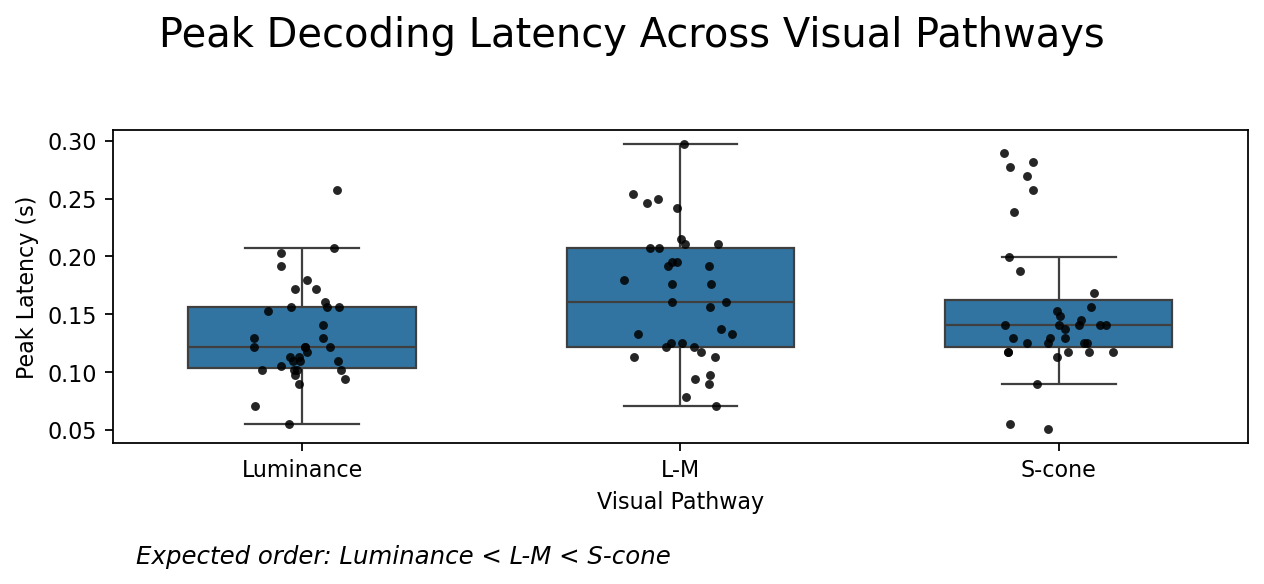

In [9]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


ROOT = Path("/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP")
USE  = "best_time"   # or "onset_time"



# -------------------------------------------------------------

def _find_csv(root: Path, hints: list[str]) -> Path:
    """Find the first *_MDS_QC_summary.csv under `root` whose name contains all hints."""
    for p in root.rglob("*_MDS_QC_summary.csv"):
        name = p.name.lower()
        if all(h in name for h in hints):
            return p
    raise FileNotFoundError(f"Could not find CSV with hints {hints} under {root}")

def _load(path: Path, label: str) -> pd.DataFrame:
    df = pd.read_csv(path, usecols=["subject", USE]).rename(columns={USE: "latency_s"})
    df["pathway"] = label
    return df


paths = {
    "Luminance": ROOT / "Luminance_NPZ/ecoc_results_01/luminance_MDS_QC_summary.csv",
    "L-M":       ROOT / "L_M_NPZ/ecoc_results_01/L-M_MDS_QC_summary.csv",
    "S-cone":    ROOT / "S_cone_NPZ/ecoc_results_01/S-cone_MDS_QC_summary.csv",
}
resolved = {}
for label, guess in paths.items():
    if guess.exists():
        resolved[label] = guess
    else:
        hints = {"Luminance": ["lum"], "L-M": ["lm"], "S-cone": ["s", "cone"]}[label]
        resolved[label] = _find_csv(ROOT, hints)

print("Using CSVs:")
for k, v in resolved.items():
    print(f"  {k}: {v}")

# Build tidy DF
df = pd.concat([
    _load(resolved["Luminance"], "Luminance"),
    _load(resolved["L-M"],       "L-M"),
    _load(resolved["S-cone"],    "S-cone"),
], ignore_index=True)

MIN_PEAK, MAX_PEAK = 0.05, 0.30  # 80–300 ms; tweak if you like
df = df[df["latency_s"].between(MIN_PEAK, MAX_PEAK)]

# Plot
order = ["Luminance", "L-M", "S-cone"]
fig, ax = plt.subplots(figsize=(8, 4.2), dpi=160)
ax = plt.gca()
sns.boxplot(data=df, x="pathway", y="latency_s", order=order, palette=COLORS, fliersize=0, width=0.6, ax=ax)
sns.stripplot(data=df, x="pathway", y="latency_s", order=order, jitter=0.15, size=4, alpha=0.85, color="k", ax=ax)
ax.set_xlabel("Visual Pathway")
ax.set_ylabel("Peak Latency (s)" if USE == "best_time" else "Onset Latency (s)")
fig.suptitle("Peak Decoding Latency Across Visual Pathways", fontsize=18, y=0.98)
ax.text(0.02, -.4, "Expected order: Luminance < L-M < S-cone",
        transform=ax.transAxes, fontsize=11, style="italic", ha="left", va="bottom")
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()



A) Peak decoding vs age  (y=peak_score vs x=age)
Luminance   n=35  slope=0.001741 per year  r=0.27  p=0.12068723402318478
L-M         n=35  slope=-0.000397 per year  r=-0.05  p=0.7754217682064635
S-cone      n=35  slope=0.0004631 per year  r=0.09  p=0.6067867396236302

B) Latency vs age  (y=latency_s vs x=age)
Luminance   n=35  slope=0.0005111 per year  r=0.17  p=0.33335181286977067
L-M         n=35  slope=0.0004766 per year  r=0.12  p=0.5034592339206921
S-cone      n=35  slope=0.001542 per year  r=0.35  p=0.03696066741423994


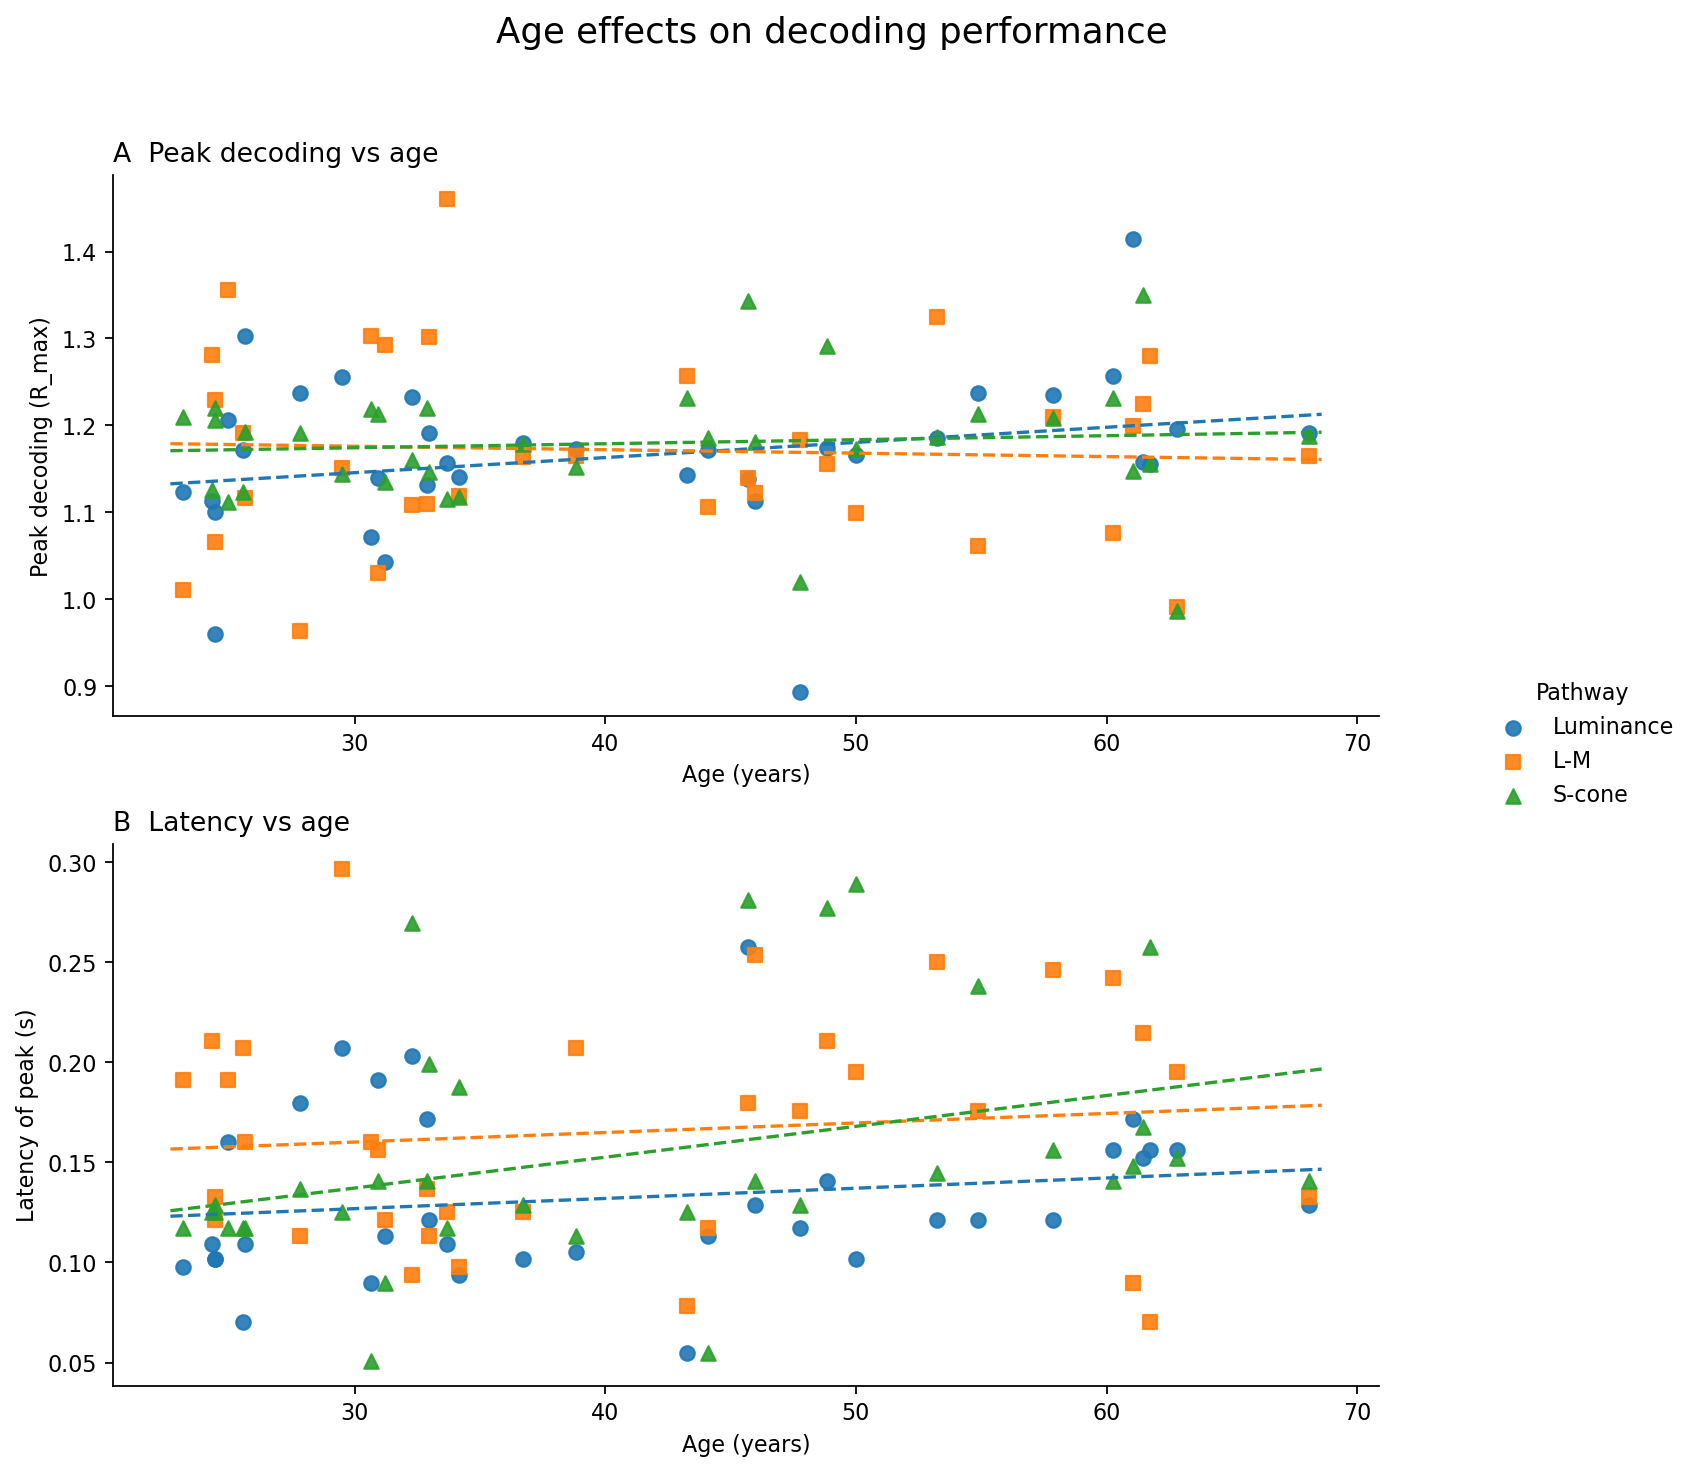

In [10]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    _HAVE_SNS = True
except Exception:
    _HAVE_SNS = False

try:
    from scipy.stats import linregress
    _HAVE_SCIPY = True
except Exception:
    _HAVE_SCIPY = False

# --------- EDIT THESE PATHS ----------
CRF = {
    "Luminance": Path("/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/Luminance_NPZ/ecoc_results_01/Luminance_NR_params.csv"),
    "L-M":       Path("/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/L_M_NPZ/ecoc_results_01/L-M_NR_params.csv"),
    "S-cone":    Path("/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/S_cone_NPZ/ecoc_results_01/S-cone_NR_params.csv"),
}
MDS = {
    "Luminance": Path("/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/Luminance_NPZ/ecoc_results_01/luminance_MDS_QC_summary.csv"),
    "L-M":       Path("/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/L_M_NPZ/ecoc_results_01/L-M_MDS_QC_summary.csv"),
    "S-cone":    Path("/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/S_cone_NPZ/ecoc_results_01/S-cone_MDS_QC_summary.csv"),
}




AGE_DATA = {
    '1001': 24.433082, '1002': 43.258931, '1004': 32.887739, '1005': 50.016085,
    '1007': 30.938349, '1008': 24.424982, '1010': 25.533835, '1011': 36.707233,
    '1014': 23.143414, '1015': 34.177179, '1018': 25.602168, '1020': 29.492620,
    '1021': 27.808921, '1022': 31.222040, '1023': 45.988624, '1024': 24.309762,
    '1026': 24.928643, '1028': 61.460422, '1029': 32.266120, '1031': 57.862927,
    '1033': 30.650755, '1034': 60.269547, '1037': 32.978090, '1038': 45.692930,
    '1039': 62.813063, '1041': 48.855213, '1042': 38.837211, '1044': 61.739803,
    '1046': 61.069016, '1049': 44.083041, '1050': 47.773625, '1052': 53.216693,
    '1057': 33.692684, '1059': 54.853967, '1064': 68.083534,
}



LAT_COL    = "best_time"          # or "onset_time"
LAT_BOUNDS = (0.05, 0.30)         # set to None to disable
SAVE_TO    = None                
# ---------------------------------------------------

order = ["Luminance", "L-M", "S-cone"]

# --- helpers ---
_age_map = {str(k): float(v) for k, v in AGE_DATA.items()}

def subj_key(x: str) -> str:
    """Extract numeric subject code (e.g., 'sub-1001' -> '1001')."""
    m = re.search(r"(\d{3,})", str(x))
    return m.group(1) if m else str(x)

def add_age(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["subj_key"] = df["subject"].map(subj_key)
    df["age"] = df["subj_key"].map(_age_map)
    return df.dropna(subset=["age"])

def load_crf(p: Path, label: str) -> pd.DataFrame:
    df = pd.read_csv(p)
    if not {"subject","R_max"}.issubset(df.columns):
        raise ValueError(f"{p.name} must have columns ['subject','R_max']; has {list(df.columns)}")
    df = (df[["subject","R_max"]]
          .groupby("subject", as_index=False).median()
          .rename(columns={"R_max":"peak_score"}))
    df["pathway"] = label
    return add_age(df)

def load_lat(p: Path, label: str, col: str) -> pd.DataFrame:
    df = pd.read_csv(p)
    if col not in df.columns and "onset_time" in df.columns:
        col = "onset_time"
    if not {"subject", col}.issubset(df.columns):
        raise ValueError(f"{p.name} must contain ['subject','{col}']; has {list(df.columns)}")
    df = (df[["subject", col]]
          .groupby("subject", as_index=False).median()
          .rename(columns={col:"latency_s"}))
    df["pathway"] = label
    df = add_age(df)
    if LAT_BOUNDS is not None:
        lo, hi = LAT_BOUNDS
        df = df[df["latency_s"].between(lo, hi)]
    return df

def fit_line(x, y):
    x = np.asarray(x); y = np.asarray(y)
    if len(x) < 2:
        return np.nan, np.nan, np.nan, np.nan
    if _HAVE_SCIPY:
        r = linregress(x, y)
        return r.slope, r.intercept, r.rvalue, r.pvalue
    # fallback (no p-value)
    m, b = np.polyfit(x, y, 1)
    r = np.corrcoef(x, y)[0, 1]
    return m, b, r, np.nan


acc = pd.concat([load_crf(CRF[k], k) for k in order], ignore_index=True)
lat = pd.concat([load_lat(MDS[k], k, LAT_COL) for k in order], ignore_index=True)
acc["pathway"] = pd.Categorical(acc["pathway"], order, ordered=True)
lat["pathway"] = pd.Categorical(lat["pathway"], order, ordered=True)


def report(df, x, y, label):
    print(f"\n{label}  (y={y} vs x={x})")
    for k in order:
        d = df[df["pathway"] == k]
        m, b, r, p = fit_line(d[x], d[y])
        print(f"{k:10s}  n={len(d):2d}  slope={m:.4g} per year  r={r:.2f}  p={p if not np.isnan(p) else 'NA'}")

report(acc, "age", "peak_score", "A) Peak decoding vs age")
report(lat, "age", "latency_s", "B) Latency vs age")

# --- figure ---
markers = {"Luminance":"o", "L-M":"s", "S-cone":"^"}
order   = ["Luminance","L-M","S-cone"]

fig, (axA, axB) = plt.subplots(
    2, 1, figsize=(10.5, 9.2), dpi=160, sharex=False
)



def _fit_and_line(ax, x, y, data, style="--"):
    from scipy.stats import linregress
    if len(data) < 2:
        return np.nan, np.nan, np.nan, np.nan
    r = linregress(data[x], data[y])
    xs = np.linspace(data[x].min()-0.5, data[x].max()+0.5, 100)
    ax.plot(xs, r.slope*xs + r.intercept, linestyle=style)
    return r.slope, r.intercept, r.rvalue, r.pvalue

for k in order:
    d = acc[acc["pathway"] == k]
    h = axA.scatter(d["age"], d["peak_score"],
                    label=k, alpha=0.9, s=42, marker=markers[k], color=COLORS[k])
    # OLS fit line
    if len(d) >= 2:
        m, b = np.polyfit(d["age"], d["peak_score"], 1)
        xs = np.linspace(d["age"].min()-0.5, d["age"].max()+0.5, 100)
        axA.plot(xs, m*xs + b, linestyle="--", color=COLORS[k])
axA.set_xlabel("Age (years)")
axA.set_ylabel("Peak decoding (R_max)")
axA.set_title("A  Peak decoding vs age", loc="left")


# ---------- Latency of peak vs age ----------
for k in order:
    d = lat[lat["pathway"] == k]
    axB.scatter(d["age"], d["latency_s"],
                label=k, alpha=0.9, s=42, marker=markers[k], color=COLORS[k])
    if len(d) >= 2:
        m, b = np.polyfit(d["age"], d["latency_s"], 1)
        xs = np.linspace(d["age"].min()-0.5, d["age"].max()+0.5, 100)
        axB.plot(xs, m*xs + b, linestyle="--", color=COLORS[k])
axB.set_xlabel("Age (years)")
axB.set_ylabel("Latency of peak (s)" if LAT_COL == "best_time" else "Onset latency (s)")
axB.set_title("B  Latency vs age", loc="left")


for ax in (axA, axB):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Age effects on decoding performance", y=0.995, fontsize=16)


handles, labels = axA.get_legend_handles_labels()
fig.legend(handles, labels, title="Pathway", frameon=False,
           loc="center left", bbox_to_anchor=(0.88, 0.5))


fig.tight_layout(rect=[0.0, 0.0, 0.84, 0.965])
plt.show()



In [ ]:
markers = {"Luminance": "o", "L-M": "s", "S-cone": "^"}
order   = ["Luminance", "L-M", "S-cone"]

def make_age_plot(df, y, ylabel, title_left, save_to=None, legend_out=True):
    """
    df: tidy DataFrame with columns ['age', y, 'pathway']
    y:  'peak_score' or 'latency_s'
    """
    fig, ax = plt.subplots(figsize=(7.6, 5.2), dpi=160)

    for k in order:
        d = df[df["pathway"] == k]
        ax.scatter(d["age"], d[y], label=k, alpha=0.9, s=46, marker=markers[k], color=COLORS[k])
        if len(d) >= 2:
            m, b = np.polyfit(d["age"], d[y], 1)
            xs = np.linspace(d["age"].min() - 0.5, d["age"].max() + 0.5, 120)
            ax.plot(xs, m*xs + b, linestyle="--", linewidth=1.2, color=COLORS[k])

    ax.set_xlabel("Age (years)")
    ax.set_ylabel(ylabel)
    ax.set_title(title_left, loc="left")

    # cosmetics
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if legend_out:
        ax.legend(title="Pathway", frameon=False,
                  loc="center left", bbox_to_anchor=(1.02, 0.5))
        fig.tight_layout(rect=[0.0, 0.0, 0.84, 1.0])  
    else:
        fig.tight_layout()

    if save_to:
        fig.savefig(save_to, dpi=300, bbox_inches="tight")
    return fig, ax


In [ ]:
# --- Figure 1: Peak decoding vs age
_ = make_age_plot(
    acc, y="peak_score",
    ylabel="Peak decoding (R_max)",
    title_left="A  Peak decoding vs age",
    save_to=None,          
    legend_out=True
)
plt.show()


In [ ]:
# --- Figure 2: Latency vs age 
_ = make_age_plot(
    lat, y="latency_s",
    ylabel=("Latency of peak (s)" if LAT_COL == "best_time" else "Onset latency (s)"),
    title_left="B  Latency vs age",
    save_to=None,        
    legend_out=True
)
plt.show()
